In [1]:
# ============================================================
# 04_clustering.ipynb — Phase 4.1: Cohort Discovery (K-Means)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_style("whitegrid")
os.makedirs('../reports/eda_figures', exist_ok=True)

# Load splits from Phase 3
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Re-load the pipeline structure, but re-fit properly on X_train only (correcting Phase 3 note)
pipeline = joblib.load('../models/preprocessing_pipeline.joblib')
pipeline.fit(X_train)   # fit only on train — no leakage from test set

X_train_transformed = pipeline.transform(X_train)
X_test_transformed = pipeline.transform(X_test)

# Save the correctly-fit pipeline, overwriting the placeholder from Phase 3
joblib.dump(pipeline, '../models/preprocessing_pipeline.joblib')

print("X_train_transformed:", X_train_transformed.shape)
print("X_test_transformed:", X_test_transformed.shape)

X_train_transformed: (55978, 120)
X_test_transformed: (13995, 120)


In [2]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

# Use a sample for speed if X_train is large (>50k rows) — silhouette is O(n^2)
sample_size = min(10000, X_train_transformed.shape[0])
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_train_transformed.shape[0], sample_size, replace=False)
X_sample = X_train_transformed[sample_idx]

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_transformed)
    inertias.append(km.inertia_)

    sample_labels = labels[sample_idx]
    sil = silhouette_score(X_sample, sample_labels)
    silhouette_scores.append(sil)
    print(f"K={k}: inertia={km.inertia_:.0f}, silhouette={sil:.4f}")

K=2: inertia=833726, silhouette=0.1057
K=3: inertia=772224, silhouette=0.0996
K=4: inertia=739924, silhouette=0.0955
K=5: inertia=712692, silhouette=0.0797
K=6: inertia=688281, silhouette=0.0827
K=7: inertia=670495, silhouette=0.0719
K=8: inertia=655178, silhouette=0.0716
K=9: inertia=642048, silhouette=0.0737
K=10: inertia=630053, silhouette=0.0702


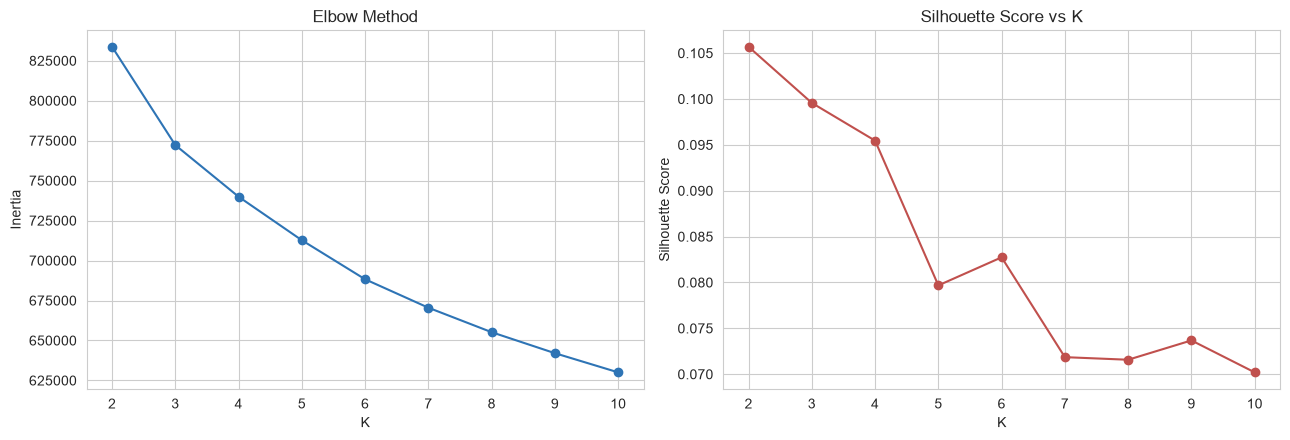


Highest silhouette score at K=2 (0.1057)
Choose K based on BOTH this score AND how interpretable the resulting cohorts are —
don't pick purely on the metric. K=3 to K=5 is typical for this kind of clinical data.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(list(k_range), inertias, marker='o', color='#2E74B5')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='#C0504D')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')

plt.tight_layout()
plt.savefig('../reports/eda_figures/elbow_and_silhouette.png', dpi=150)
plt.show()

best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"\nHighest silhouette score at K={best_k} ({max(silhouette_scores):.4f})")
print("Choose K based on BOTH this score AND how interpretable the resulting cohorts are —")
print("don't pick purely on the metric. K=3 to K=5 is typical for this kind of clinical data.")

In [4]:
FINAL_K = 4   # <-- set this based on what you see in the elbow/silhouette plots

In [5]:
kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
train_clusters = kmeans_final.fit_predict(X_train_transformed)
test_clusters = kmeans_final.predict(X_test_transformed)

X_train['cluster'] = train_clusters
X_test['cluster'] = test_clusters

full_sil = silhouette_score(X_sample, kmeans_final.predict(X_sample) if False else train_clusters[sample_idx])
db_score = davies_bouldin_score(X_train_transformed, train_clusters)

print(f"Final K={FINAL_K}")
print(f"Silhouette Score: {full_sil:.4f}  (target: ≥ 0.25)")
print(f"Davies-Bouldin Index: {db_score:.4f}  (lower is better)")
print(f"\nCluster sizes:\n{pd.Series(train_clusters).value_counts().sort_index()}")

joblib.dump(kmeans_final, '../models/kmeans_model.joblib')
print("\nSaved: models/kmeans_model.joblib")

Final K=4
Silhouette Score: 0.0955  (target: ≥ 0.25)
Davies-Bouldin Index: 2.4722  (lower is better)

Cluster sizes:
0     8406
1     9094
2    23903
3    14575
Name: count, dtype: int64

Saved: models/kmeans_model.joblib


In [6]:
profile_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                 'num_medications', 'number_diagnoses', 'total_prior_utilization',
                 'num_meds_changed']
profile_cols = [c for c in profile_cols if c in X_train.columns]

cohort_profile = X_train.groupby('cluster')[profile_cols].mean().round(2)
cohort_profile['cluster_size'] = X_train['cluster'].value_counts().sort_index()
cohort_profile['readmit_rate'] = y_train.groupby(X_train['cluster']).mean().round(3)

print(cohort_profile)

# Save as a markdown report
with open('../reports/cohort_profiles.md', 'w') as f:
    f.write("# Cohort Profiles\n\n")
    f.write(cohort_profile.to_markdown())
print("\nSaved: reports/cohort_profiles.md")

         time_in_hospital  num_lab_procedures  num_procedures  \
cluster                                                         
0                    8.11               57.45            3.46   
1                    4.57               44.75            1.00   
2                    3.54               39.34            1.04   
3                    3.09               39.31            1.13   

         num_medications  number_diagnoses  total_prior_utilization  \
cluster                                                               
0                  27.42              8.24                     0.57   
1                  16.91              7.67                     0.69   
2                  13.05              7.28                     0.53   
3                  12.46              6.26                     0.51   

         num_meds_changed  cluster_size  readmit_rate  
cluster                                                
0                    0.29          8406         0.111  
1             

In [7]:
# Give each cluster a human-readable name based on what you see above — edit this manually
cohort_names = {
    0: "Low-complexity, single-admission patients",
    1: "High-utilization elderly / chronic patients",
    2: "Moderate-medication, stable diabetic patients",
    3: "High-emergency, frequent-inpatient patients",
    # adjust based on your actual cohort_profile output
}
print(cohort_names)

{0: 'Low-complexity, single-admission patients', 1: 'High-utilization elderly / chronic patients', 2: 'Moderate-medication, stable diabetic patients', 3: 'High-emergency, frequent-inpatient patients'}


Explained variance by 2 PCA components: 29.67%


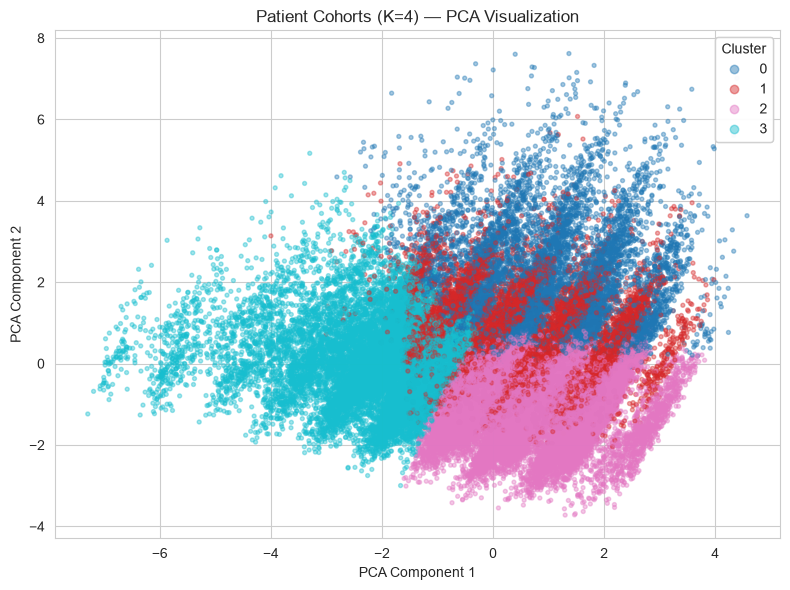

In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_transformed)

print(f"Explained variance by 2 PCA components: {pca.explained_variance_ratio_.sum():.2%}")

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=train_clusters,
                      cmap='tab10', alpha=0.4, s=8)
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster", loc="upper right")
ax.add_artist(legend1)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title(f'Patient Cohorts (K={FINAL_K}) — PCA Visualization')
plt.tight_layout()
plt.savefig('../reports/eda_figures/cluster_scatter.png', dpi=150)
plt.show()